In [7]:
import pandas as pd

df = pd.read_csv("D:/AI-Based Airline Complaint Severity Detection & Service Risk Classification System/venv/Scripts/data/processed/labeled_data.csv")

print(df.columns)

Index(['Unnamed: 0', 'Airline Name', 'Overall_Rating', 'Review_Title',
       'Review Date', 'Verified', 'Review', 'Aircraft', 'Type Of Traveller',
       'Seat Type', 'Route', 'Date Flown', 'Seat Comfort',
       'Cabin Staff Service', 'Food & Beverages', 'Ground Service',
       'Inflight Entertainment', 'Wifi & Connectivity', 'Value For Money',
       'Recommended', 'full_review_text', 'clean_text', 'review_length',
       'severity_label', 'risk_flag', 'severity_id'],
      dtype='object')


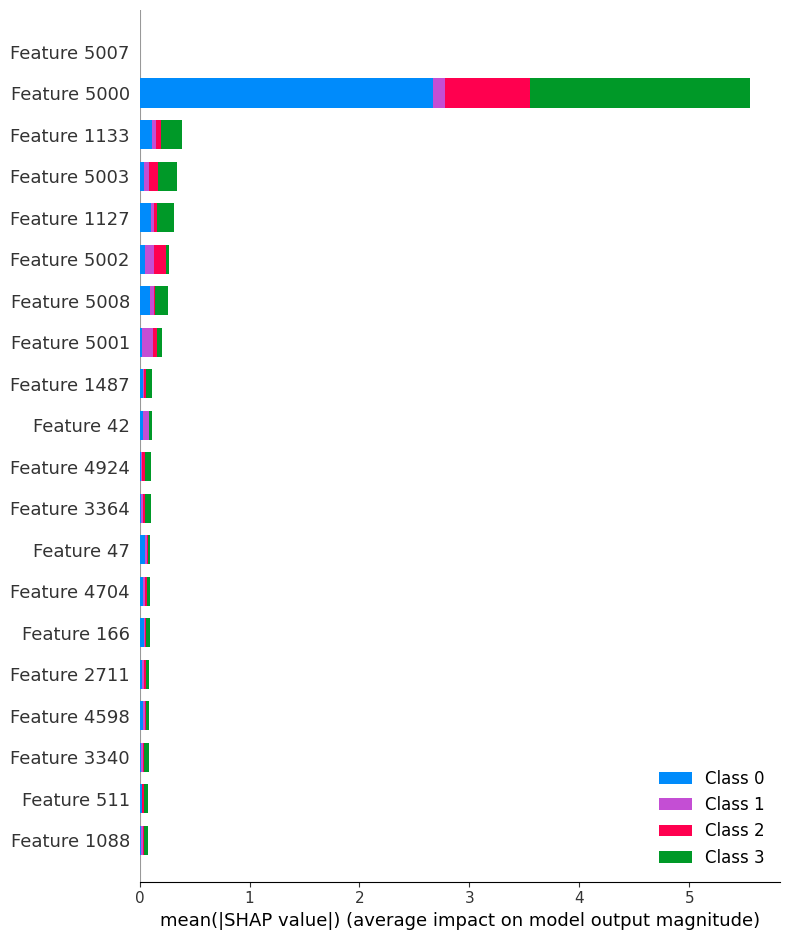

In [12]:
import joblib
import pandas as pd
import shap
import scipy.sparse as sp
import matplotlib.pyplot as plt

# Load model and vectorizer
model = joblib.load("D:/AI-Based Airline Complaint Severity Detection & Service Risk Classification System/venv/Scripts/models/severity/severity_model.pkl")
tfidf = joblib.load("D:/AI-Based Airline Complaint Severity Detection & Service Risk Classification System/venv/Scripts/models/vectorizers/tfidf.pkl")

# Load data
df = pd.read_csv("D:/AI-Based Airline Complaint Severity Detection & Service Risk Classification System/venv/Scripts/data/processed/labeled_data.csv")

# Text features
X_text = tfidf.transform(df["clean_text"])

# Numeric features (USE ACTUAL COLUMN NAMES FROM df.columns)
numeric_cols = ["Overall_Rating",
    "Seat Comfort",
    "Cabin Staff Service",
    "Food & Beverages",
    "Ground Service",
    "Inflight Entertainment",
    "Wifi & Connectivity",
    "Value For Money",
    "review_length"
] 

X_numeric = df[numeric_cols].values

# Combine text + numeric
X_combined = sp.hstack((X_text, X_numeric)).tocsr()

# SHAP
X_sample = X_combined[:200]

explainer = shap.Explainer(model, X_sample)
shap_values = explainer(X_sample)

shap.summary_plot(shap_values, X_sample)